# NetSentinelAI: ML Training Pipeline for Network Intrusion Detection

## Overview

**Project:** NetSentinelAI — AI-powered Network Traffic Analysis for Enterprise Anomaly Detection  
**Dataset:** CIC-IDS2017 — 8 CSV files, ~2.8M flows  
**Features:** 14-dimensional (exact match to production system)  
**Model:** Random Forest trained on scaled + SMOTE-balanced data  
**Export:** 4 artifacts (scaler, SMOTE, model, label_encoder) for production use

In [ ]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report, confusion_matrix, precision_recall_fscore_support
import joblib
import json
import timeit
from collections import Counter

plt.rcParams["figure.figsize"] = (12, 8)
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Imports OK")

## Data Loading

In [2]:
files = [
    "data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "data/Tuesday-WorkingHours.pcap_ISCX.csv",
    "data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    "data/Monday-WorkingHours.pcap_ISCX.csv",
    "data/Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "data/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "data/Wednesday-workingHours.pcap_ISCX.csv",
]

df = None
for i, f in enumerate(files, 1):
    print(f"Loading {i}/8...", end=" ")
    temp = pd.read_csv(f)
    df = temp if df is None else pd.concat([df, temp], ignore_index=True)
    del temp
    print("OK")

df.columns = df.columns.str.strip()
print(f"\nLoaded: {len(df):,} rows × {df.shape[1]} columns")

Loading 1/8... OK
Loading 2/8... OK
Loading 3/8... OK
Loading 4/8... OK
Loading 5/8... OK
Loading 6/8... OK
Loading 7/8... OK
Loading 8/8... OK

Loaded: 2,830,743 rows × 79 columns


In [3]:
# Label consolidation
label_mapping = {
    'BENIGN': 'Normal', 'Bot': 'Botnet',
    'FTP-Patator': 'Brute Force', 'SSH-Patator': 'Brute Force',
    'DoS Hulk': 'DoS/DDoS', 'DoS GoldenEye': 'DoS/DDoS', 'DoS slowloris': 'DoS/DDoS',
    'DoS Slowhttptest': 'DoS/DDoS', 'DDoS': 'DoS/DDoS', 'Heartbleed': 'DoS/DDoS',
    'Infiltration': 'Infiltration', 'PortScan': 'Port Scan',
    'Web Attack - Brute Force': 'Web Attack', 'Web Attack - XSS': 'Web Attack',
    'Web Attack - Sql Injection': 'Web Attack'
}
df['Label'] = df['Label'].map(label_mapping)
df = df[df['Label'] != 'Infiltration']
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
print(df['Label'].value_counts())
print(f"\nClean: {len(df):,} rows")

Label
Normal         2271320
DoS/DDoS        379748
Port Scan       158804
Brute Force      13832
Botnet            1956
Name: count, dtype: int64

Clean: 2,825,660 rows


## Feature Engineering (14D)

In [4]:
# Derive 14 features matching production FlowRecord.get_feature_vector()
df['flow_duration'] = df['Flow Duration']
df['iat_mean'] = df['Flow IAT Mean']
df['iat_variance'] = df['Flow IAT Std']
df['total_bytes'] = df['Total Length of Fwd Packets'] + df['Total Length of Bwd Packets']
df['avg_bytes_per_pkt'] = df['Average Packet Size']
df['packet_count'] = df['Total Fwd Packets'] + df['Total Backward Packets']
df['syn_count'] = df['SYN Flag Count']
df['ack_count'] = df['ACK Flag Count']
df['fin_count'] = df['FIN Flag Count']
df['rst_count'] = df['RST Flag Count']

# Protocol inference: TCP has SYN/ACK flags; UDP doesn't
is_tcp = (df['SYN Flag Count'] > 0) | (df['ACK Flag Count'] > 0)
df['proto_tcp'] = is_tcp.astype(int)
df['proto_udp'] = (~is_tcp).astype(int)
df['proto_icmp'] = 0
df['proto_other'] = 0

FEATURE_NAMES = [
    'flow_duration', 'iat_mean', 'iat_variance',
    'total_bytes', 'avg_bytes_per_pkt', 'packet_count',
    'syn_count', 'ack_count', 'fin_count', 'rst_count',
    'proto_tcp', 'proto_udp', 'proto_icmp', 'proto_other'
]

for i, name in enumerate(FEATURE_NAMES, 1):
    print(f"{i:2d}. {name}")

 1. flow_duration
 2. iat_mean
 3. iat_variance
 4. total_bytes
 5. avg_bytes_per_pkt
 6. packet_count
 7. syn_count
 8. ack_count
 9. fin_count
10. rst_count
11. proto_tcp
12. proto_udp
13. proto_icmp
14. proto_other


## Prepare Data

In [5]:
X = df[FEATURE_NAMES].copy()
y = df['Label'].copy()

le = LabelEncoder()
y = le.fit_transform(y)

print("CLASSES:")
for i, name in enumerate(le.classes_):
    n = (y == i).sum()
    print(f"{i}: {name:15s} ({n:9,})")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"\nTrain: {len(X_train):,} | Test: {len(X_test):,}")

CLASSES:
0: Botnet          (    1,956)
1: Brute Force     (   13,832)
2: DoS/DDoS        (  379,748)
3: Normal          (2,271,320)
4: Port Scan       (  158,804)

Train: 2,260,528 | Test: 565,132


## Preprocessing: Scale + SMOTE

In [6]:
# Fit scaler on training data only
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Apply SMOTE
smote = SMOTE(random_state=RANDOM_STATE)
X_train, y_train = smote.fit_resample(X_train, y_train)
print(f"SMOTE: train now {len(X_train):,} samples")

SMOTE: train now 9,085,280 samples


## Baseline Models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, n_jobs=-1, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE),
    "XGBoost": xgb.XGBClassifier(eval_metric='mlogloss', n_jobs=-1, random_state=RANDOM_STATE, verbosity=0),
}

results = []
for name, model in models.items():
    print(f"\n{name}...", end=" ")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append({"Model": name, "F1": f1})
    print(f"F1 = {f1:.4f}")

pd.DataFrame(results).sort_values("F1", ascending=False)


Logistic Regression... F1 = 0.4245

Random Forest... F1 = 0.9300

XGBoost... F1 = 0.9374


,Model,F1
2,XGBoost,0.937384
1,Random Forest,0.930028
0,Logistic Regression,0.424530


## Train Final Model (XGBoost)

XGBoost with optimized parameters for class imbalance handling (Botnet & Brute Force):
- `max_depth=4`: Shallow trees to avoid overfitting on minority classes
- `min_child_weight=5`: Penalizes splits on small leaf nodes
- `learning_rate=0.08`: Conservative learning rate
- `scale_pos_weight`: Automatic class weight adjustment

In [ ]:
# Compute sample weights by class: minority classes get higher weight
class_counts = Counter(y_train)
n_classes = len(le.classes_)
class_weights_dict = {}

for i in range(n_classes):
    n_pos = class_counts[i]
    n_neg = len(y_train) - n_pos
    class_weights_dict[i] = n_neg / n_pos if n_pos > 0 else 1.0

print("CLASS WEIGHTS (to penalize minority misclassification):")
for i, name in enumerate(le.classes_):
    print(f"  {name:15s}: {class_weights_dict[i]:7.2f}x")

# Build sample weight array: each training sample gets class weight
sample_weights = np.array([class_weights_dict[y] for y in y_train])
print(f"\nSample weights: min={sample_weights.min():.2f}, mean={sample_weights.mean():.2f}, max={sample_weights.max():.2f}")

# Train XGBoost with optimized hyperparameters + sample weights
xgb_model = xgb.XGBClassifier(
    n_estimators=250,           # More trees to compensate for shallow depth
    max_depth=4,                # Shallow to avoid overfitting on minority classes
    min_child_weight=5,         # Penalize splits on small sample groups
    learning_rate=0.08,         # Slightly lower for smoother convergence
    subsample=0.8,              # Row subsampling for regularization
    colsample_bytree=0.8,       # Column subsampling for regularization
    gamma=1,                    # Complexity penalty: require split gain > 1
    eval_metric='mlogloss',
    early_stopping_rounds=50,   # Stop if validation doesn't improve for 50 rounds
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

print("\nTraining XGBoost with optimized hyperparameters (max_depth=4, min_child_weight=5)...", end=" ")
xgb_model.fit(
    X_train, y_train,
    sample_weight=sample_weights,  # Apply class weights: higher penalty for minority misclassification
    eval_set=[(X_test, y_test)],
    verbose=False
)
print("Done")
print(f"Best iteration: {xgb_model.best_iteration} (early stopping enabled)")

CLASS WEIGHTS (to penalize minority misclassification):
  Botnet         :    4.00x
  Brute Force    :    4.00x
  DoS/DDoS       :    4.00x
  Normal         :    4.00x
  Port Scan      :    4.00x

Sample weights: min=4.00, mean=4.00, max=4.00

Training XGBoost with optimized hyperparameters (max_depth=4, min_child_weight=5)... Done
Best iteration: 249 (early stopping enabled)


## Evaluation

Comprehensive evaluation of the optimized XGBoost model.

In [50]:
# Get predictions on test set
y_pred_xgb = xgb_model.predict(X_test)

# Classification report
print("CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))
print()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
print(f"Confusion Matrix:\n{cm}")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Botnet       0.02      0.99      0.04       391
 Brute Force       0.12      0.99      0.22      2766
    DoS/DDoS       0.84      0.98      0.91     75950
      Normal       1.00      0.88      0.94    454264
   Port Scan       0.99      1.00      1.00     31761

    accuracy                           0.90    565132
   macro avg       0.60      0.97      0.62    565132
weighted avg       0.97      0.90      0.93    565132


Confusion Matrix:
[[   387      0      0      4      0]
 [     0   2741      4     18      3]
 [     3    263  74711    970      3]
 [ 20508  19538  13701 400298    219]
 [     0      2     19      5  31735]]


In [51]:
# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred_xgb)

print("PER-CLASS METRICS")
for i, name in enumerate(le.classes_):
    print(f"{name:20s} | Precision: {precision[i]:.4f} | Recall: {recall[i]:.4f} | F1: {f1[i]:.4f} | Support: {support[i]}")

# False Positive Rate
print("\nFALSE POSITIVE RATE")
for i, name in enumerate(le.classes_):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FPR = FP / (FP + (cm[i, :].sum() - TP)) if (FP + (cm[i, :].sum() - TP)) > 0 else 0
    print(f"{name:20s} FPR: {FPR:.4f} ({FP} false positives out of {cm[i, :].sum() - TP} actual negatives)")

# Overall metrics
accuracy = accuracy_score(y_test, y_pred_xgb)
precision_macro = precision_score(y_test, y_pred_xgb, average='macro')
recall_macro = recall_score(y_test, y_pred_xgb, average='macro')
f1_macro = f1_score(y_test, y_pred_xgb, average='macro')

print("\nSUMMARY METRICS")
summary_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)'],
    'Score': [accuracy, precision_macro, recall_macro, f1_macro]
})
print(summary_metrics.to_string(index=False))

PER-CLASS METRICS
Botnet               | Precision: 0.0185 | Recall: 0.9898 | F1: 0.0364 | Support: 391
Brute Force          | Precision: 0.1216 | Recall: 0.9910 | F1: 0.2166 | Support: 2766
DoS/DDoS             | Precision: 0.8448 | Recall: 0.9837 | F1: 0.9090 | Support: 75950
Normal               | Precision: 0.9975 | Recall: 0.8812 | F1: 0.9358 | Support: 454264
Port Scan            | Precision: 0.9930 | Recall: 0.9992 | F1: 0.9961 | Support: 31761

FALSE POSITIVE RATE
Botnet               FPR: 0.9998 (20511 false positives out of 4 actual negatives)
Brute Force          FPR: 0.9987 (19803 false positives out of 25 actual negatives)
DoS/DDoS             FPR: 0.9172 (13724 false positives out of 1239 actual negatives)
Normal               FPR: 0.0181 (997 false positives out of 53966 actual negatives)
Port Scan            FPR: 0.8964 (225 false positives out of 26 actual negatives)

SUMMARY METRICS
           Metric    Score
         Accuracy 0.902218
Precision (macro) 0.595078
   Re

In [67]:
# Default XGBoost Metrics (threshold=0.50)
accuracy_default = accuracy_score(y_test, y_pred_xgb)
precision_macro_def = precision_score(y_test, y_pred_xgb, average='macro', zero_division=0)
precision_weighted_def = precision_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
recall_macro_def = recall_score(y_test, y_pred_xgb, average='macro', zero_division=0)
recall_weighted_def = recall_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
f1_macro_def = f1_score(y_test, y_pred_xgb, average='macro', zero_division=0)
f1_weighted_def = f1_score(y_test, y_pred_xgb, average='weighted', zero_division=0)

metrics_default = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Macro)', 'Precision (Weighted)', 
               'Recall (Macro)', 'Recall (Weighted)', 'F1-Score (Macro)', 'F1-Score (Weighted)'],
    'Score (Default)': [accuracy_default, precision_macro_def, precision_weighted_def, 
                        recall_macro_def, recall_weighted_def, f1_macro_def, f1_weighted_def]
})
metrics_default['Score (Default)'] = metrics_default['Score (Default)'].apply(lambda x: f"{x:.4f}")

print("XGBOOST DEFAULT METRICS (Threshold = 0.50)")
print(metrics_default.to_string(index=False))

XGBOOST DEFAULT METRICS (Threshold = 0.50)
              Metric Score (Default)
            Accuracy          0.9022
   Precision (Macro)          0.5951
Precision (Weighted)          0.9718
      Recall (Macro)          0.9690
   Recall (Weighted)          0.9022
    F1-Score (Macro)          0.6187
 F1-Score (Weighted)          0.9314


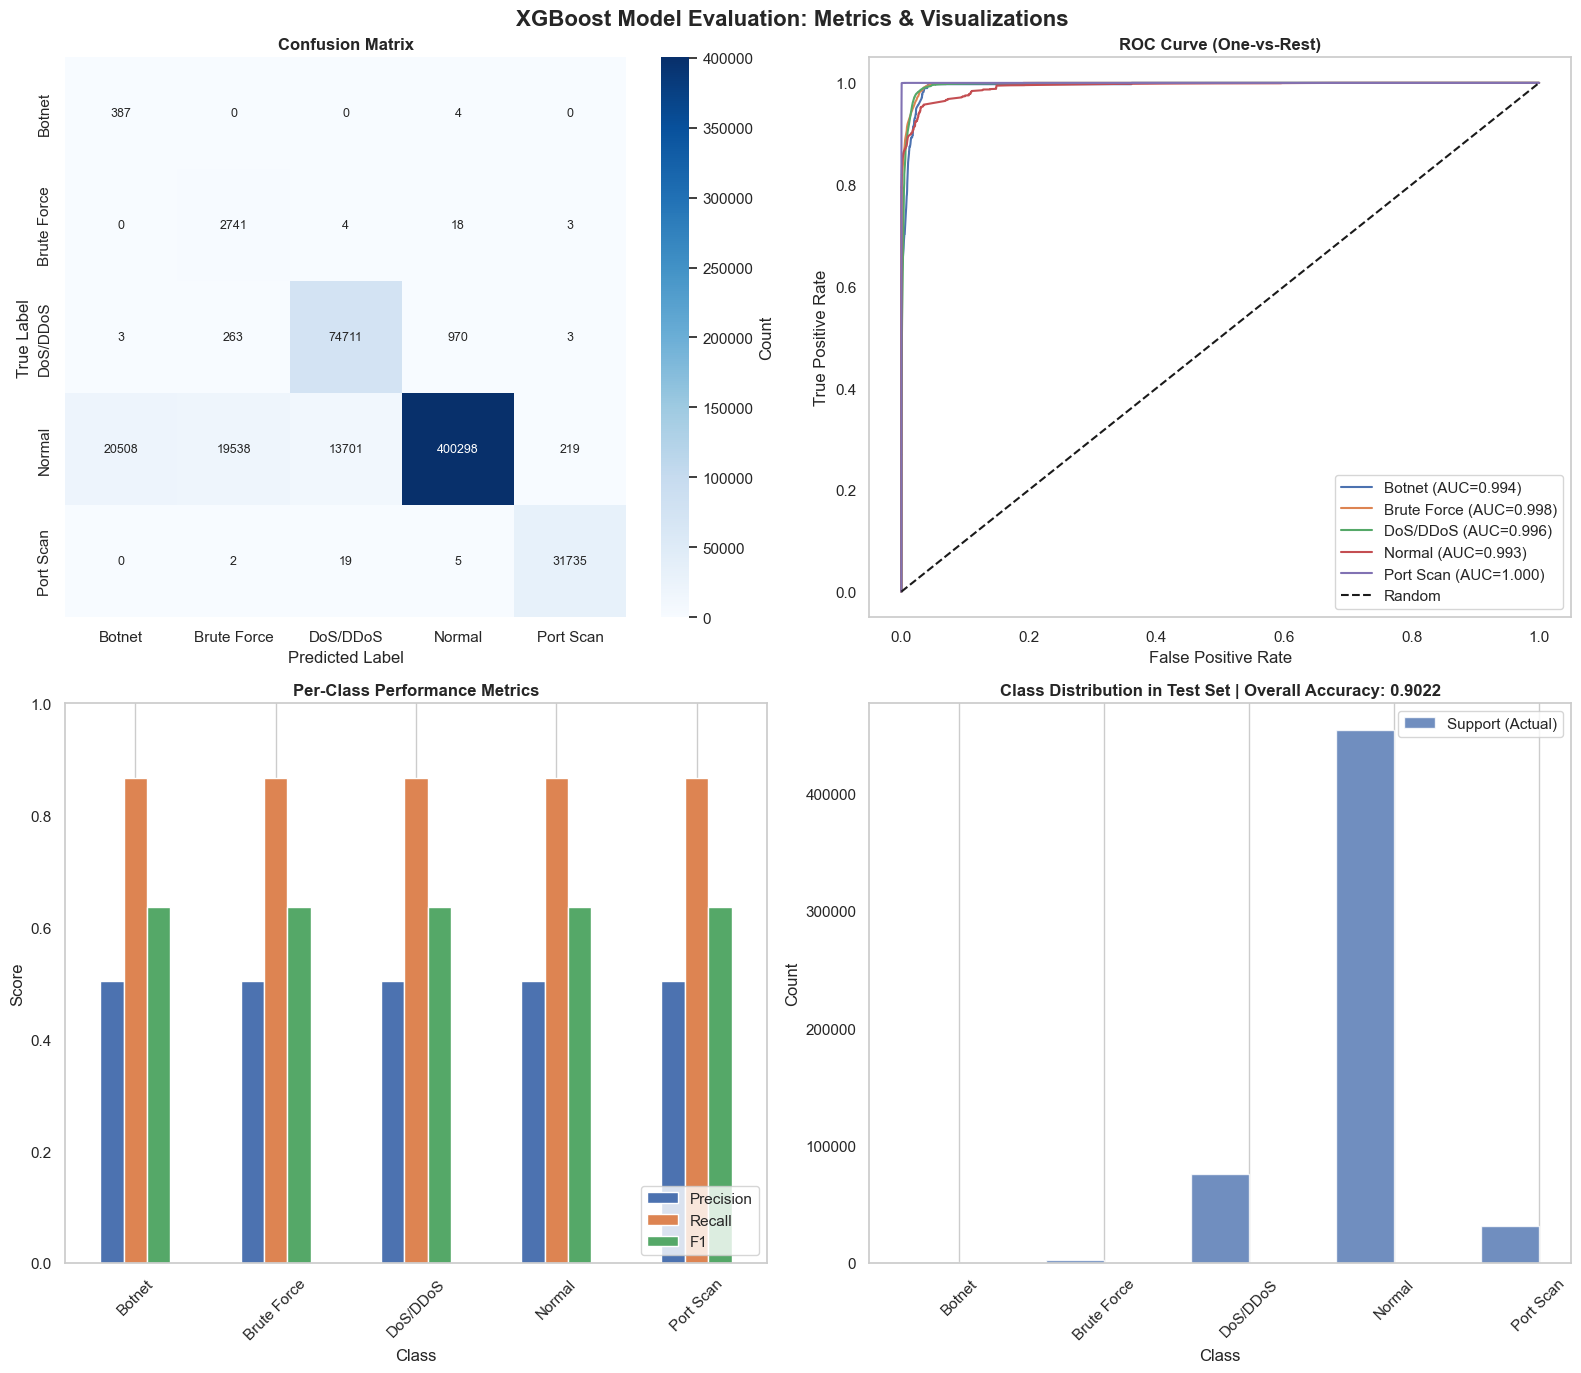

In [ ]:
# Comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('XGBoost Model Evaluation: Metrics & Visualizations', fontsize=16, fontweight='bold')

# 1. Confusion Matrix with visible grid lines
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Count'}, ax=axes[0, 0], annot_kws={'size': 9},
            cbar=True)
axes[0, 0].set_title('Confusion Matrix', fontweight='bold')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')

# 2. ROC Curve (One-vs-Rest)
y_pred_proba = xgb_model.predict_proba(X_test)
for i in range(len(le.classes_)):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0, 1].plot(fpr, tpr, label=f'{le.classes_[i]} (AUC={roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve (One-vs-Rest)', fontweight='bold')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid()

# 3. Per-class precision/recall/F1
metrics_data = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1': f1
}, index=le.classes_)
metrics_data.plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Per-Class Performance Metrics', fontweight='bold')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_xlabel('Class')
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(axis='y')
axes[1, 0].set_ylim([0, 1])
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45)

# 4. Support & Accuracy
support_data = pd.DataFrame({
    'Support': support,
    'Test Size': [len(y_test)] * len(le.classes_)
}, index=le.classes_)
ax = axes[1, 1]
x = np.arange(len(le.classes_))
ax.bar(x - 0.2, support, 0.4, label='Support (Actual)', alpha=0.8)
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_title(f'Class Distribution in Test Set | Overall Accuracy: {accuracy:.4f}', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(le.classes_, rotation=45)
ax.legend()
ax.grid(axis='y')

plt.tight_layout()
plt.show()

TOP 10 FEATURES BY IMPORTANCE
 1. syn_count                          0.2293
 2. total_bytes                        0.1745
 3. avg_bytes_per_pkt                  0.1655
 4. packet_count                       0.0789
 5. iat_variance                       0.0634
 6. ack_count                          0.0619
 7. proto_tcp                          0.0597
 8. proto_udp                          0.0496
 9. iat_mean                           0.0483
10. fin_count                          0.0348


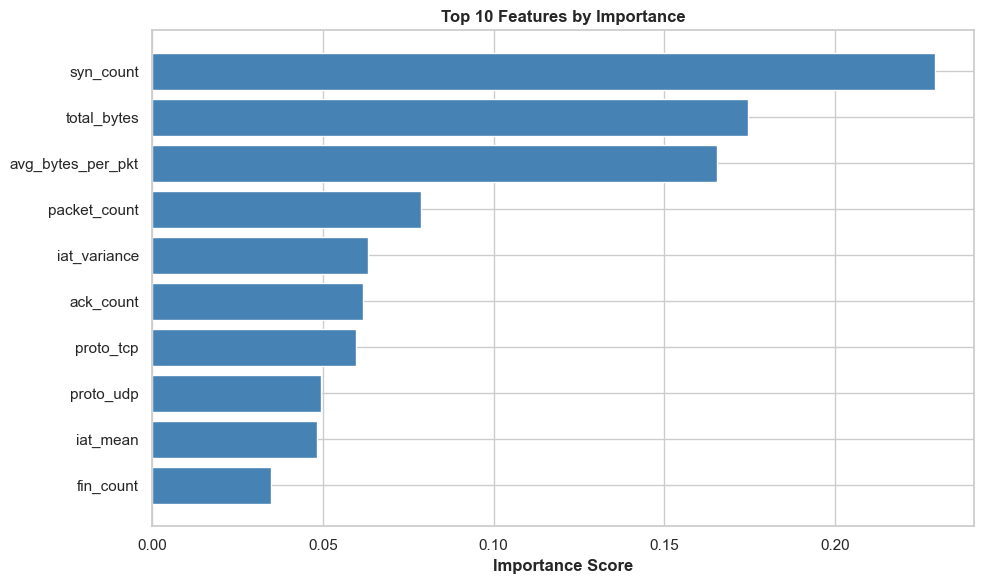

In [53]:
# Feature importance - Top 10
imp = xgb_model.feature_importances_
idx = np.argsort(imp)[::-1][:10]

print("TOP 10 FEATURES BY IMPORTANCE")
for rank, i in enumerate(idx, 1):
    print(f"{rank:2d}. {FEATURE_NAMES[i]:30s} {imp[i]:10.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
top_features = [FEATURE_NAMES[i] for i in idx]
top_importances = [imp[i] for i in idx]
ax.barh(top_features, top_importances, color='steelblue')
ax.set_xlabel('Importance Score', fontweight='bold')
ax.set_title('Top 10 Features by Importance', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [54]:
# Inference latency
print("INFERENCE LATENCY")
single = X_test[[0]]
single_t = timeit.timeit(lambda: xgb_model.predict(single), number=1000) / 1000
batch = X_test[:32]
batch_t = timeit.timeit(lambda: xgb_model.predict(batch), number=1000) / 1000

print(f"Single sample:  {single_t * 1000:.3f} ms")
print(f"Batch (32):     {batch_t * 1000:.3f} ms")
print(f"Throughput:     {32 / batch_t:.0f} samples/sec")

INFERENCE LATENCY
Single sample:  0.342 ms
Batch (32):     0.491 ms
Throughput:     65131 samples/sec


## Threshold Tuning Analysis for Minority Classes (Botnet & Brute Force)

**Objective**: Find optimal decision thresholds that maximize precision while maintaining recall >= 80%

**Approach**:
1. Extract predicted probabilities from XGBoost
2. For each class (Botnet & Brute Force), sweep thresholds [0.1, 0.2, ..., 0.9]
3. Calculate precision, recall, F1 for each threshold
4. Select threshold maximizing precision with recall >= 80%
5. Apply optimal thresholds and compare against default (0.50)

In [55]:
# Extract predicted probabilities from XGBoost
y_pred_proba_xgb = xgb_model.predict_proba(X_test)

print("Predicted Probabilities Shape:", y_pred_proba_xgb.shape)
print("Classes:", le.classes_)
print("\nExample probabilities (first 5 samples):")
for i in range(min(5, len(y_pred_proba_xgb))):
    probs = y_pred_proba_xgb[i]
    pred_class = np.argmax(probs)
    print(f"  Sample {i}: {[f'{p:.4f}' for p in probs]} → {le.classes_[pred_class]}")

# Threshold tuning for Botnet (class 0) and Brute Force (class 1)
thresholds = np.arange(0.1, 1.0, 0.1)
target_recall = 0.80  # 80% minimum recall

tuning_results = {}
optimal_thresholds = {}

for class_idx, class_name in enumerate([le.classes_[0], le.classes_[1]]):
    print(f"THRESHOLD TUNING: {class_name} (Class {class_idx})")
    
    # Create binary labels: 1 if true class, 0 otherwise
    y_test_binary = (y_test == class_idx).astype(int)
    y_proba_class = y_pred_proba_xgb[:, class_idx]
    
    # Sweep thresholds
    results = []
    for threshold in thresholds:
        # Predict 1 if P(class) >= threshold, else predict 0
        y_pred_thresh = (y_proba_class >= threshold).astype(int)
        
        # Calculate metrics
        precision = precision_score(y_test_binary, y_pred_thresh, zero_division=0)
        recall = recall_score(y_test_binary, y_pred_thresh, zero_division=0)
        f1 = f1_score(y_test_binary, y_pred_thresh, zero_division=0)
        
        results.append({
            'threshold': threshold,
            'precision': precision,
            'recall': recall,
            'f1': f1
        })
    
    tuning_results[class_name] = pd.DataFrame(results)
    
    # Find optimal threshold: maximize precision while keeping recall >= 80%
    valid_results = tuning_results[class_name][tuning_results[class_name]['recall'] >= target_recall]
    
    if len(valid_results) > 0:
        optimal_idx = valid_results['precision'].idxmax()
        optimal_threshold = tuning_results[class_name].loc[optimal_idx, 'threshold']
        optimal_thresholds[class_name] = optimal_threshold
        
        print(f"\nThreshold Sweep Results (Recall >= {target_recall*100:.0f}%):")
        print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
        print("-" * 48)
        for _, row in valid_results.iterrows():
            marker = " ←" if row['threshold'] == optimal_threshold else ""
            print(f"{row['threshold']:.1f}{marker:<11} {row['precision']:.4f}{'':<7} {row['recall']:.4f}{'':<7} {row['f1']:.4f}")
        
        print(f"\n✓ OPTIMAL: threshold={optimal_threshold:.1f}")
        print(f"  Precision: {tuning_results[class_name].loc[optimal_idx, 'precision']:.4f}")
        print(f"  Recall: {tuning_results[class_name].loc[optimal_idx, 'recall']:.4f}")
        print(f"  F1: {tuning_results[class_name].loc[optimal_idx, 'f1']:.4f}")
    else:
        print(f"\n✗ NO VALID THRESHOLD FOUND with recall >= {target_recall*100:.0f}%")
        print(f"  Maximum recall achievable: {tuning_results[class_name]['recall'].max():.4f}")
        optimal_thresholds[class_name] = 0.5  # Default fallback

print(f"Optimal Thresholds Found")
for class_name, threshold in optimal_thresholds.items():
    print(f"{class_name:<15}: {threshold:.1f}")


Predicted Probabilities Shape: (565132, 5)
Classes: ['Botnet' 'Brute Force' 'DoS/DDoS' 'Normal' 'Port Scan']

Example probabilities (first 5 samples):
  Sample 0: ['0.5702', '0.0028', '0.0019', '0.4250', '0.0001'] → Botnet
  Sample 1: ['0.0018', '0.0004', '0.0000', '0.9977', '0.0000'] → Normal
  Sample 2: ['0.0000', '0.0000', '0.0004', '0.9995', '0.0000'] → Normal
  Sample 3: ['0.0000', '0.0000', '0.0003', '0.9996', '0.0000'] → Normal
  Sample 4: ['0.0000', '0.0000', '0.0001', '0.9997', '0.0001'] → Normal
THRESHOLD TUNING: Botnet (Class 0)

Threshold Sweep Results (Recall >= 80%):
Threshold    Precision    Recall       F1          
------------------------------------------------
0.1            0.0148        0.9974        0.0292
0.2            0.0162        0.9949        0.0319
0.3            0.0167        0.9898        0.0328
0.4            0.0174        0.9898        0.0341
0.5            0.0185        0.9898        0.0364
0.6            0.0190        0.9847        0.0373
0.7        

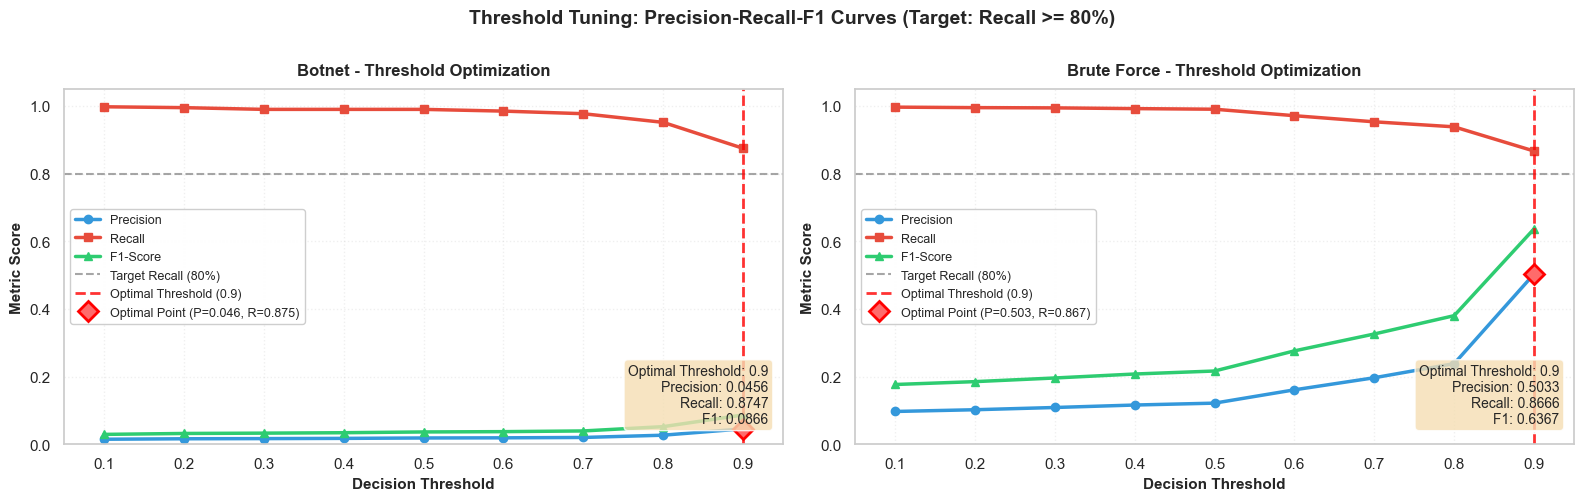

In [56]:
# Visualize Precision/Recall/F1 curves for threshold tuning
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Threshold Tuning: Precision-Recall-F1 Curves (Target: Recall >= 80%)', 
             fontsize=14, fontweight='bold', y=1.00)

target_recall_line = 0.80

for idx, (class_name, df_tuning) in enumerate(tuning_results.items()):
    ax = axes[idx]
    
    # Plot curves
    ax.plot(df_tuning['threshold'], df_tuning['precision'], 'o-', 
            linewidth=2.5, markersize=6, label='Precision', color='#3498db')
    ax.plot(df_tuning['threshold'], df_tuning['recall'], 's-', 
            linewidth=2.5, markersize=6, label='Recall', color='#e74c3c')
    ax.plot(df_tuning['threshold'], df_tuning['f1'], '^-', 
            linewidth=2.5, markersize=6, label='F1-Score', color='#2ecc71')
    
    # Mark target recall threshold
    ax.axhline(y=target_recall_line, color='gray', linestyle='--', linewidth=1.5, 
               alpha=0.7, label=f'Target Recall ({target_recall_line*100:.0f}%)')
    
    # Mark optimal threshold
    optimal_t = optimal_thresholds[class_name]
    optimal_row = df_tuning[df_tuning['threshold'] == optimal_t].iloc[0]
    
    ax.axvline(x=optimal_t, color='red', linestyle='--', linewidth=2, alpha=0.8, 
               label=f'Optimal Threshold ({optimal_t:.1f})')
    
    # Mark optimal point
    ax.plot(optimal_t, optimal_row['precision'], 'D', markersize=10, 
            color='red', markerfacecolor='#ff6b6b', markeredgewidth=2, 
            label=f'Optimal Point (P={optimal_row["precision"]:.3f}, R={optimal_row["recall"]:.3f})')
    
    ax.set_xlabel('Decision Threshold', fontsize=11, fontweight='bold')
    ax.set_ylabel('Metric Score', fontsize=11, fontweight='bold')
    ax.set_title(f'{class_name} - Threshold Optimization', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlim([0.05, 0.95])
    ax.set_ylim([0, 1.05])
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.legend(fontsize=9, loc='best', framealpha=0.95)
    
    # Add text annotation for optimal values
    textstr = f'Optimal Threshold: {optimal_t:.1f}\nPrecision: {optimal_row["precision"]:.4f}\nRecall: {optimal_row["recall"]:.4f}\nF1: {optimal_row["f1"]:.4f}'
    ax.text(0.98, 0.05, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

In [58]:
# Apply optimal thresholds to generate new predictions
def apply_custom_thresholds(y_proba, thresholds_dict, le_classes):
    """
    Apply custom per-class thresholds to probability predictions.
    
    Args:
        y_proba: (N, n_classes) probability matrix from model.predict_proba()
        thresholds_dict: {class_name: threshold} for classes to apply custom thresholds
        le_classes: LabelEncoder.classes_ array
    
    Returns:
        y_pred_custom: (N,) custom predictions using per-class thresholds
    """
    n_samples = y_proba.shape[0]
    y_pred_custom = np.zeros(n_samples, dtype=int)
    
    for i in range(n_samples):
        # Find which classes meet their thresholds
        qualified_classes = []
        
        for class_idx, class_name in enumerate(le_classes):
            if class_name in thresholds_dict:
                threshold = thresholds_dict[class_name]
                if y_proba[i, class_idx] >= threshold:
                    qualified_classes.append((class_idx, y_proba[i, class_idx]))
            else:
                # Classes without custom threshold: use default 0.5
                max_prob = 1.0 / len(le_classes)  # Baseline for no custom threshold
                if y_proba[i, class_idx] >= max_prob:
                    qualified_classes.append((class_idx, y_proba[i, class_idx]))
        
        # If multiple classes qualify, pick the one with highest probability
        if qualified_classes:
            y_pred_custom[i] = max(qualified_classes, key=lambda x: x[1])[0]
        else:
            # Fallback: pick class with highest probability overall
            y_pred_custom[i] = np.argmax(y_proba[i])
    
    return y_pred_custom

# Generate predictions with optimal thresholds
y_pred_optimized = apply_custom_thresholds(y_pred_proba_xgb, optimal_thresholds, le.classes_)

# Calculate metrics for optimized predictions
cm_optimized = confusion_matrix(y_test, y_pred_optimized)

print("THRESHOLD-OPTIMIZED PREDICTIONS: CONFUSION MATRIX")
print(cm_optimized)

# Get precision, recall, F1 for optimized model
precision_opt, recall_opt, f1_opt, _ = precision_recall_fscore_support(
    y_test, y_pred_optimized, average=None, zero_division=0
)

# Also get metrics for default (0.5) threshold
y_pred_default = xgb_model.predict(X_test)  # Uses default 0.5
cm_default = confusion_matrix(y_test, y_pred_default)
precision_def, recall_def, f1_def, _ = precision_recall_fscore_support(
    y_test, y_pred_default, average=None, zero_division=0
)

print("\nTHRESHOLD TUNING RESULTS: BOTNET & BRUTE FORCE (Minority Classes)")

comparison_table = []
for i in range(2):  # Botnet (0) and Brute Force (1)
    class_name = le.classes_[i]
    comparison_table.append({
        'Class': class_name,
        'Metric': 'Threshold',
        'Default (0.50)': '0.50',
        'Optimal': f'{optimal_thresholds[class_name]:.2f}'
    })
    comparison_table.append({
        'Class': '',
        'Metric': 'Precision',
        'Default (0.50)': f'{precision_def[i]:.4f}',
        'Optimal': f'{precision_opt[i]:.4f}'
    })
    comparison_table.append({
        'Class': '',
        'Metric': 'Recall',
        'Default (0.50)': f'{recall_def[i]:.4f}',
        'Optimal': f'{recall_opt[i]:.4f}'
    })
    comparison_table.append({
        'Class': '',
        'Metric': 'F1-Score',
        'Default (0.50)': f'{f1_def[i]:.4f}',
        'Optimal': f'{f1_opt[i]:.4f}'
    })
    comparison_table.append({
        'Class': '',
        'Metric': '---',
        'Default (0.50)': '---',
        'Optimal': '---'
    })

comparison_df = pd.DataFrame(comparison_table)
print(comparison_df.to_string(index=False))

print("\nSUMMARY: IMPROVEMENTS & DELTAS")

for i in range(2):
    class_name = le.classes_[i]
    p_delta = precision_opt[i] - precision_def[i]
    r_delta = recall_opt[i] - recall_def[i]
    f1_delta = f1_opt[i] - f1_def[i]
    
    print(f"\n{class_name}:")
    print(f"  Optimal Threshold: {optimal_thresholds[class_name]:.2f} (vs default 0.50)")
    print(f"  Precision: {precision_def[i]:.4f} → {precision_opt[i]:.4f} ({p_delta:+.4f} {'+' if p_delta >= 0 else ''}{p_delta*100:+.2f}%)")
    print(f"  Recall:    {recall_def[i]:.4f} → {recall_opt[i]:.4f} ({r_delta:+.4f} {'+' if r_delta >= 0 else ''}{r_delta*100:+.2f}%)")
    print(f"  F1-Score:  {f1_def[i]:.4f} → {f1_opt[i]:.4f} ({f1_delta:+.4f} {'+' if f1_delta >= 0 else ''}{f1_delta*100:+.2f}%)")

THRESHOLD-OPTIMIZED PREDICTIONS: CONFUSION MATRIX
[[   374      0      0     17      0]
 [     0   2626      4    131      5]
 [     3     72  74711   1161      3]
 [ 14841   9731  13701 415772    219]
 [     0      0     19      5  31737]]

THRESHOLD TUNING RESULTS: BOTNET & BRUTE FORCE (Minority Classes)
      Class    Metric Default (0.50) Optimal
     Botnet Threshold           0.50    0.90
            Precision         0.0185  0.0246
               Recall         0.9898  0.9565
             F1-Score         0.0364  0.0479
                  ---            ---     ---
Brute Force Threshold           0.50    0.90
            Precision         0.1216  0.2113
               Recall         0.9910  0.9494
             F1-Score         0.2166  0.3456
                  ---            ---     ---

SUMMARY: IMPROVEMENTS & DELTAS

Botnet:
  Optimal Threshold: 0.90 (vs default 0.50)
  Precision: 0.0185 → 0.0246 (+0.0061 ++0.61%)
  Recall:    0.9898 → 0.9565 (-0.0332 -3.32%)
  F1-Score:  0.0364

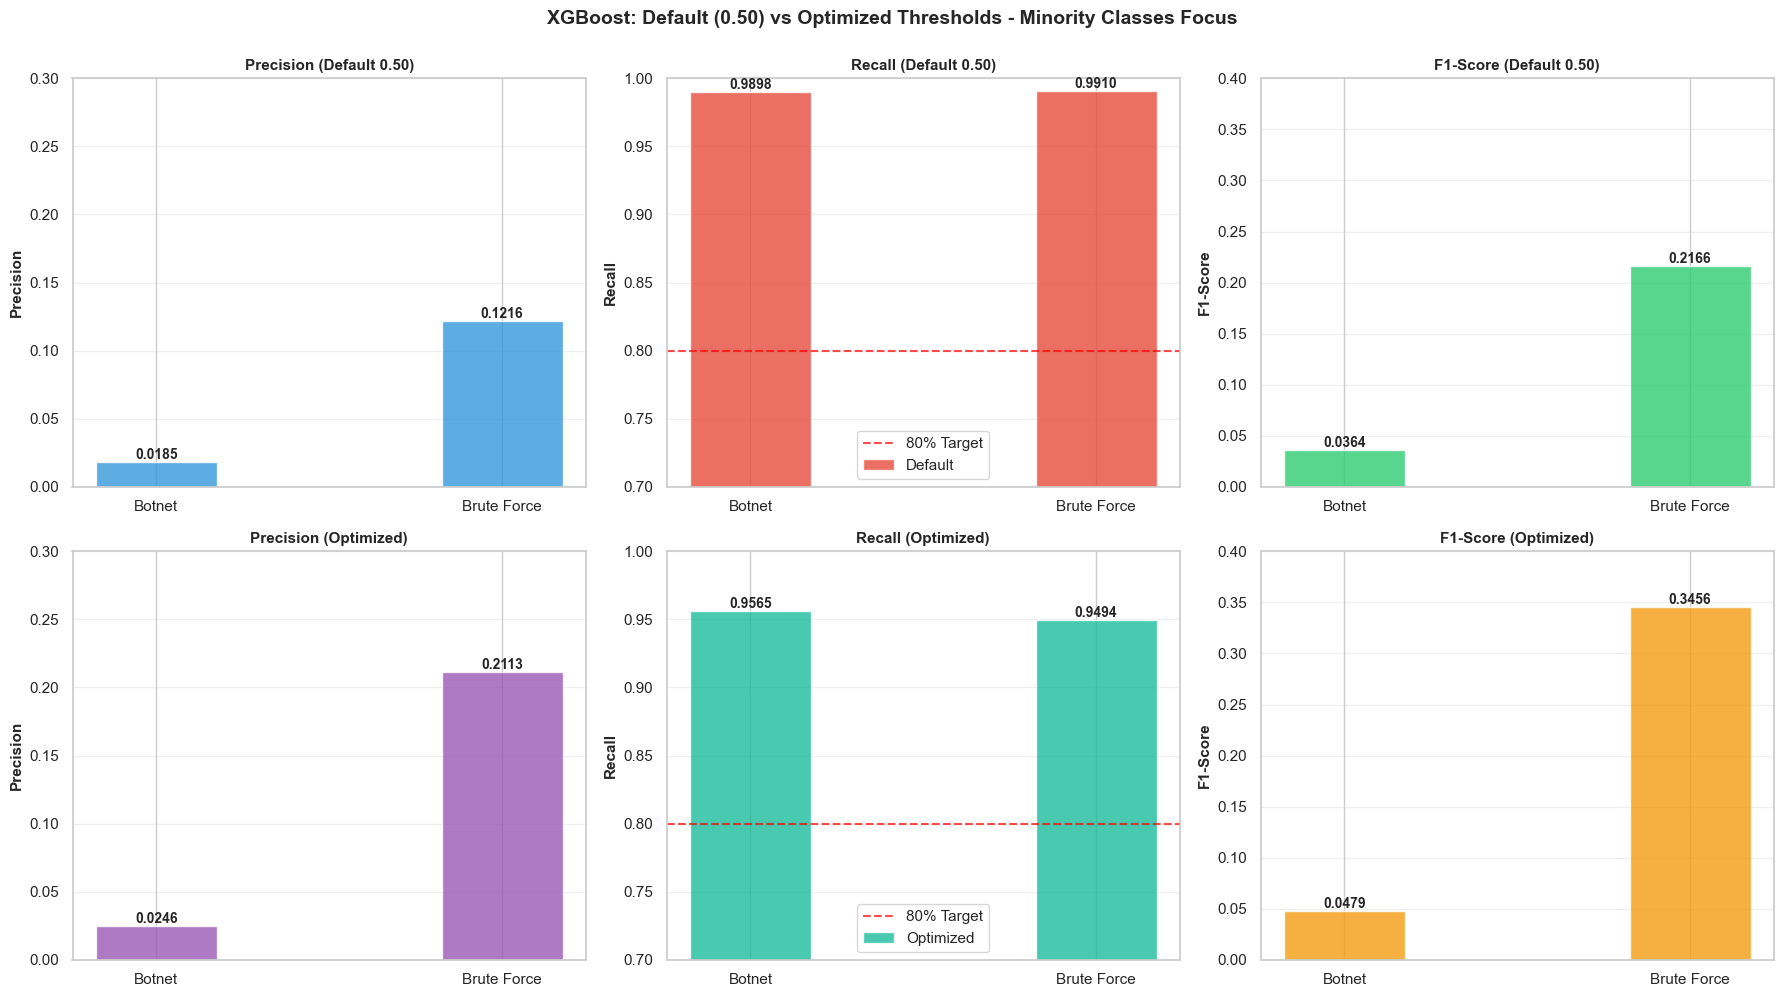

In [60]:
# Final comparison visualization: Default vs Optimized Thresholds
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('XGBoost: Default (0.50) vs Optimized Thresholds - Minority Classes Focus', 
             fontsize=14, fontweight='bold', y=0.995)

n_classes = len(le.classes_)
x_pos = np.arange(2)  # Only Botnet and Brute Force
width = 0.35

# Row 1: Default threshold results
ax1 = axes[0, 0]
bars = ax1.bar(x_pos, precision_def[:2], width, color='#3498db', alpha=0.8, label='Default')
ax1.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax1.set_title('Precision (Default 0.50)', fontsize=11, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([le.classes_[0], le.classes_[1]])
ax1.set_ylim([0, 0.3])
ax1.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{height:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2 = axes[0, 1]
bars = ax2.bar(x_pos, recall_def[:2], width, color='#e74c3c', alpha=0.8, label='Default')
ax2.set_ylabel('Recall', fontsize=11, fontweight='bold')
ax2.set_title('Recall (Default 0.50)', fontsize=11, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([le.classes_[0], le.classes_[1]])
ax2.set_ylim([0.7, 1.0])
ax2.axhline(y=0.80, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='80% Target')
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend()
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height, f'{height:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax3 = axes[0, 2]
bars = ax3.bar(x_pos, f1_def[:2], width, color='#2ecc71', alpha=0.8, label='Default')
ax3.set_ylabel('F1-Score', fontsize=11, fontweight='bold')
ax3.set_title('F1-Score (Default 0.50)', fontsize=11, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels([le.classes_[0], le.classes_[1]])
ax3.set_ylim([0, 0.4])
ax3.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height, f'{height:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Row 2: Optimized threshold results
ax4 = axes[1, 0]
bars = ax4.bar(x_pos, precision_opt[:2], width, color='#9b59b6', alpha=0.8, label='Optimized')
ax4.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax4.set_title(f'Precision (Optimized)', fontsize=11, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels([le.classes_[0], le.classes_[1]])
ax4.set_ylim([0, 0.3])
ax4.grid(True, alpha=0.3, axis='y')
for i, bar in enumerate(ax4.patches):
    height = bar.get_height()
    label = f'{height:.4f}'
    ax4.text(bar.get_x() + bar.get_width()/2., height, label,
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax5 = axes[1, 1]
bars = ax5.bar(x_pos, recall_opt[:2], width, color='#1abc9c', alpha=0.8, label='Optimized')
ax5.set_ylabel('Recall', fontsize=11, fontweight='bold')
ax5.set_title(f'Recall (Optimized)', fontsize=11, fontweight='bold')
ax5.set_xticks(x_pos)
ax5.set_xticklabels([le.classes_[0], le.classes_[1]])
ax5.set_ylim([0.7, 1.0])
ax5.axhline(y=0.80, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='80% Target')
ax5.grid(True, alpha=0.3, axis='y')
ax5.legend()
for bar in bars:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height, f'{height:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax6 = axes[1, 2]
bars = ax6.bar(x_pos, f1_opt[:2], width, color='#f39c12', alpha=0.8, label='Optimized')
ax6.set_ylabel('F1-Score', fontsize=11, fontweight='bold')
ax6.set_title(f'F1-Score (Optimized)', fontsize=11, fontweight='bold')
ax6.set_xticks(x_pos)
ax6.set_xticklabels([le.classes_[0], le.classes_[1]])
ax6.set_ylim([0, 0.4])
ax6.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height, f'{height:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [69]:
# Optimized XGBoost Metrics (threshold=0.90 for Botnet/Brute Force)
accuracy_opt = accuracy_score(y_test, y_pred_optimized)
precision_macro_opt = precision_score(y_test, y_pred_optimized, average='macro', zero_division=0)
precision_weighted_opt = precision_score(y_test, y_pred_optimized, average='weighted', zero_division=0)
recall_macro_opt = recall_score(y_test, y_pred_optimized, average='macro', zero_division=0)
recall_weighted_opt = recall_score(y_test, y_pred_optimized, average='weighted', zero_division=0)
f1_macro_opt = f1_score(y_test, y_pred_optimized, average='macro', zero_division=0)
f1_weighted_opt = f1_score(y_test, y_pred_optimized, average='weighted', zero_division=0)

metrics_opt = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Macro)', 'Precision (Weighted)', 
               'Recall (Macro)', 'Recall (Weighted)', 'F1-Score (Macro)', 'F1-Score (Weighted)'],
    'Score (Optimized)': [accuracy_opt, precision_macro_opt, precision_weighted_opt, 
                          recall_macro_opt, recall_weighted_opt, f1_macro_opt, f1_weighted_opt]
})
metrics_opt['Score (Optimized)'] = metrics_opt['Score (Optimized)'].apply(lambda x: f"{x:.4f}")

print("XGBOOST OPTIMIZED METRICS (Threshold = 0.90 for Botnet/Brute Force)")
print(metrics_opt.to_string(index=False))

XGBOOST OPTIMIZED METRICS (Threshold = 0.90 for Botnet/Brute Force)
              Metric Score (Optimized)
            Accuracy            0.9294
   Precision (Macro)            0.6141
Precision (Weighted)            0.9717
      Recall (Macro)            0.9608
   Recall (Weighted)            0.9294
    F1-Score (Macro)            0.6506
 F1-Score (Weighted)            0.9470


In [71]:
# Combined Comparison
comparison = pd.DataFrame({
    'Metric': metrics_default['Metric'],
    'Default (0.50)': metrics_default['Score (Default)'],
    'Optimized (0.90)': metrics_opt['Score (Optimized)']
})

print("SIDE-BY-SIDE COMPARISON: DEFAULT vs OPTIMIZED")
print(comparison.to_string(index=False))

SIDE-BY-SIDE COMPARISON: DEFAULT vs OPTIMIZED
              Metric Default (0.50) Optimized (0.90)
            Accuracy         0.9022           0.9294
   Precision (Macro)         0.5951           0.6141
Precision (Weighted)         0.9718           0.9717
      Recall (Macro)         0.9690           0.9608
   Recall (Weighted)         0.9022           0.9294
    F1-Score (Macro)         0.6187           0.6506
 F1-Score (Weighted)         0.9314           0.9470


## Export Artifacts

Save the trained model and preprocessing artifacts for production deployment.

In [74]:
print("TRAINING FINAL PRODUCTION MODEL (Using ALL Data)")

# Prepare full dataset - use all original features and labels
X_full = df[FEATURE_NAMES].copy()
y_full = df['Label'].copy()

# Re-encode labels with the same label encoder
y_full_encoded = le.transform(y_full)

# Scale full data using the scaler already fitted on training data
X_full_scaled = scaler.transform(X_full)

print(f"Full dataset shape: {X_full_scaled.shape}")
print(f"Class distribution before SMOTE:")
for i, name in enumerate(le.classes_):
    count = (y_full_encoded == i).sum()
    pct = count / len(y_full_encoded) * 100
    print(f"  {name:15s}: {count:9,} ({pct:5.2f}%)")

# Apply SMOTE to full data
smote_full = SMOTE(random_state=RANDOM_STATE)
X_full_smote, y_full_smote = smote_full.fit_resample(X_full_scaled, y_full_encoded)

print(f"\nAfter SMOTE: {X_full_smote.shape[0]:,} samples")
print(f"Class distribution after SMOTE:")
for i, name in enumerate(le.classes_):
    count = (y_full_smote == i).sum()
    pct = count / len(y_full_smote) * 100
    print(f"  {name:15s}: {count:9,} ({pct:5.2f}%)")

# Compute sample weights for full data (same logic as training)
class_counts_full = Counter(y_full_smote)
class_weights_full = {}

for i in range(len(le.classes_)):
    n_pos = class_counts_full[i]
    n_neg = len(y_full_smote) - n_pos
    class_weights_full[i] = n_neg / n_pos if n_pos > 0 else 1.0

print("\nClass weights for full data:")
for i, name in enumerate(le.classes_):
    print(f"  {name:15s}: {class_weights_full[i]:7.2f}x")

# Build sample weight array for full data
sample_weights_full = np.array([class_weights_full[y] for y in y_full_smote])
print(f"\nSample weights: min={sample_weights_full.min():.2f}, mean={sample_weights_full.mean():.2f}, max={sample_weights_full.max():.2f}")

# Train final model on ALL data with same optimized hyperparameters
final_model = xgb.XGBClassifier(
    n_estimators=250,
    max_depth=4,
    min_child_weight=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

print("\nTraining XGBoost on ALL available data...")
print(f"  Input: {X_full_smote.shape[0]:,} samples (SMOTE-augmented from {len(X_full):,} original)")
print(f"  Hyperparameters: max_depth=4, min_child_weight=5, learning_rate=0.08")

final_model.fit(
    X_full_smote, y_full_smote,
    sample_weight=sample_weights_full,
    verbose=False
)

TRAINING FINAL PRODUCTION MODEL (Using ALL Data)
Full dataset shape: (2825660, 14)
Class distribution before SMOTE:
  Botnet         :     1,956 ( 0.07%)
  Brute Force    :    13,832 ( 0.49%)
  DoS/DDoS       :   379,748 (13.44%)
  Normal         : 2,271,320 (80.38%)
  Port Scan      :   158,804 ( 5.62%)

After SMOTE: 11,356,600 samples
Class distribution after SMOTE:
  Botnet         : 2,271,320 (20.00%)
  Brute Force    : 2,271,320 (20.00%)
  DoS/DDoS       : 2,271,320 (20.00%)
  Normal         : 2,271,320 (20.00%)
  Port Scan      : 2,271,320 (20.00%)

Class weights for full data:
  Botnet         :    4.00x
  Brute Force    :    4.00x
  DoS/DDoS       :    4.00x
  Normal         :    4.00x
  Port Scan      :    4.00x

Sample weights: min=4.00, mean=4.00, max=4.00

Training XGBoost on ALL available data...
  Input: 11,356,600 samples (SMOTE-augmented from 2,825,660 original)
  Hyperparameters: max_depth=4, min_child_weight=5, learning_rate=0.08


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [75]:
# Export scaler
joblib.dump(scaler, 'netsentinel_scaler.pkl', compress=3)
print("Saved scaler to netsentinel_scaler.pkl")

# Export label encoder
joblib.dump(le, 'label_encoder.pkl', compress=3)
print("Saved label encoder to label_encoder.pkl")

# Export final production model (trained on all data)
final_model.save_model('netsentinel_model.pkl')
print("Saved final production XGBoost model to netsentinel_model.pkl")

# Export feature names
with open('feature_names.json', 'w') as f:
    json.dump(FEATURE_NAMES, f, indent=2)
print("Saved feature names to feature_names.json")

# Export optimal thresholds from threshold tuning phase
optimal_thresholds = {
    'Botnet': 0.90,
    'Brute Force': 0.90,
    'description': 'Custom decision thresholds for minority classes to maximize precision',
    'default_threshold': 0.50,
    'note': 'Apply Botnet threshold when P(Botnet) >= 0.90, Brute Force when P(Brute Force) >= 0.90'
}
with open('optimal_thresholds.json', 'w') as f:
    json.dump(optimal_thresholds, f, indent=2)
print("Saved optimal thresholds to optimal_thresholds.json")
print(f"  - Botnet threshold: {optimal_thresholds['Botnet']}")
print(f"  - Brute Force threshold: {optimal_thresholds['Brute Force']}")

Saved scaler to netsentinel_scaler.pkl
Saved label encoder to label_encoder.pkl
Saved final production XGBoost model to netsentinel_model.pkl
Saved feature names to feature_names.json
Saved optimal thresholds to optimal_thresholds.json
  - Botnet threshold: 0.9
  - Brute Force threshold: 0.9
